In [1]:
import numpy as np
import cv2
from scipy.fft import fft2 as scipy_fft2, ifft2 as scipy_ifft2
from numpy.fft import fft2 as numpy_fft2, ifft2 as numpy_ifft2
import tensorflow as tf
import torch
import timeit
import json

# Генерація сигналу
def signal_generation(size):
    np.random.seed(0)
    x = np.linspace(0, 1, size)
    y = np.linspace(0, 1, size)
    X, Y = np.meshgrid(x, y)
    signal = np.sin(2 * np.pi * 50 * X) + np.sin(2 * np.pi * 120 * Y) + 0.5 * np.random.randn(size, size)
    return signal.astype(np.float32)

def compare_fft(size):
    signal = signal_generation(size)
    
    scipy_fft_func, scipy_ifft_func = scipy_fft2, scipy_ifft2
    numpy_fft_func, numpy_ifft_func = numpy_fft2, numpy_ifft2
    tf_fft_func, tf_ifft_func = tf.signal.fft2d, tf.signal.ifft2d
    cv2_fft_func = lambda x: cv2.dft(np.float32(x), flags=cv2.DFT_COMPLEX_OUTPUT)
    cv2_ifft_func = lambda x: cv2.idft(x, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)
    torch_fft_func = lambda x: torch.fft.fft2(x)
    torch_ifft_func = lambda x: torch.fft.ifft2(x)

    scipy_fft_time = timeit.timeit(lambda: scipy_fft_func(signal), number=10)
    scipy_fft = scipy_fft_func(signal)
    scipy_ifft_time = timeit.timeit(lambda: scipy_ifft_func(scipy_fft), number=10)
    scipy_transformed_back = scipy_ifft_func(scipy_fft)
    scipy_mse = np.mean((signal - scipy_transformed_back.real)**2)

    numpy_fft_time = timeit.timeit(lambda: numpy_fft_func(signal), number=10)
    numpy_fft = numpy_fft_func(signal)
    numpy_ifft_time = timeit.timeit(lambda: numpy_ifft_func(numpy_fft), number=10)
    numpy_transformed_back = numpy_ifft_func(numpy_fft)
    numpy_mse = np.mean((signal - numpy_transformed_back.real)**2)

    signal_tf = tf.convert_to_tensor(signal)

    tf_fft_time = timeit.timeit(lambda: tf_fft_func(tf.cast(signal_tf, tf.complex64)), number=10)
    tf_fft = tf_fft_func(tf.cast(signal_tf, tf.complex64))
    tf_ifft_time = timeit.timeit(lambda: tf_ifft_func(tf_fft), number=10)
    tf_transformed_back = tf_ifft_func(tf_fft_func(tf.cast(signal_tf, tf.complex64)))
    tf_mse = np.mean((signal - tf_transformed_back.numpy().real)**2)

    signal_torch = torch.tensor(signal).to("cuda" if torch.cuda.is_available() else "cpu")
    torch_fft_time = timeit.timeit(lambda: torch_fft_func(signal_torch), number=10)
    torch_fft = torch_fft_func(signal_torch)
    torch_ifft_time = timeit.timeit(lambda: torch_ifft_func(torch_fft), number=10)
    torch_transformed_back = torch_ifft_func(torch_fft_func(signal_torch)).to("cpu")
    torch_mse = np.mean((signal - torch_transformed_back.numpy().real)**2)

    cv2_fft_time = timeit.timeit(lambda: cv2_fft_func(signal), number=10)
    cv2_fft = cv2_fft_func(signal)
    cv2_ifft_time = timeit.timeit(lambda: cv2_ifft_func(cv2_fft), number=10)
    cv2_transformed_back = cv2_ifft_func(cv2_fft_func(signal))
    cv2_mse = np.mean((signal - cv2_transformed_back)**2)

    return {
        'scipy_fft_time': scipy_fft_time, 'scipy_ifft_time': scipy_ifft_time, 'scipy_mse': scipy_mse,
        'numpy_fft_time': numpy_fft_time, 'numpy_ifft_time': numpy_ifft_time, 'numpy_mse': numpy_mse,
        'tf_fft_time': tf_fft_time, 'tf_ifft_time': tf_ifft_time, 'tf_mse': tf_mse,
        'cv2_fft_time': cv2_fft_time, 'cv2_ifft_time': cv2_ifft_time, 'cv2_mse': cv2_mse,
        'torch_fft_time': torch_fft_time, 'torch_ifft_time': torch_ifft_time, 'torch_mse': torch_mse
    }

sizes = [32, 64, 128, 256, 512, 1024, 2048, 4096] 
results = {
    'scipy_fft_time': [], 'scipy_ifft_time': [], 'scipy_mse': [],
    'numpy_fft_time': [], 'numpy_ifft_time': [], 'numpy_mse': [],
    'tf_fft_time': [], 'tf_ifft_time': [], 'tf_mse': [],
    'cv2_fft_time': [], 'cv2_ifft_time': [], 'cv2_mse': [],
    'torch_fft_time': [], 'torch_ifft_time': [], 'torch_mse': []
}

for size in sizes:
    result = compare_fft(size)
    for key in result:
        results[key].append(result[key])

with open('fft_results.json', 'w') as f:
    results_copy = {k: [float(x) for x in v] for k, v in results.items()}
    results_copy['sizes'] = sizes
    json.dump(results_copy, f, indent=4)

In [2]:
import matplotlib.pyplot as plt

# Список бібліотек в тому порядку, як у словнику results
libs = ['scipy', 'numpy', 'tf', 'cv2', 'torch']

def plot_metric(results, sizes, metric_suffix, title, ylabel, use_log_y=False):
    plt.figure(figsize=(8, 5))

    for lib in libs:
        key = f"{lib}_{metric_suffix}"  # напр. 'scipy_fft_time'
        if key not in results:
            continue
        plt.plot(sizes, results[key], marker='o', label=lib)

    plt.title(title)
    plt.xlabel("Розмір сигналу (N x N)")
    plt.ylabel(ylabel)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    if use_log_y:
        plt.yscale('log')
    plt.xscale('log', base=2)  # зручно, бо 32, 64, 128...
    plt.legend()
    plt.tight_layout()
    plt.show()

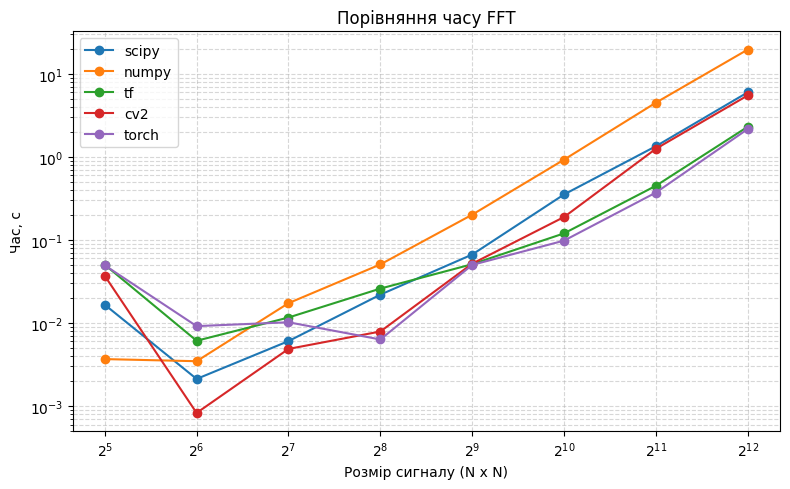

In [3]:
# Графік часу FFT
plot_metric(
    results,
    sizes,
    metric_suffix='fft_time',
    title='Порівняння часу FFT',
    ylabel='Час, с',
    use_log_y=True
)

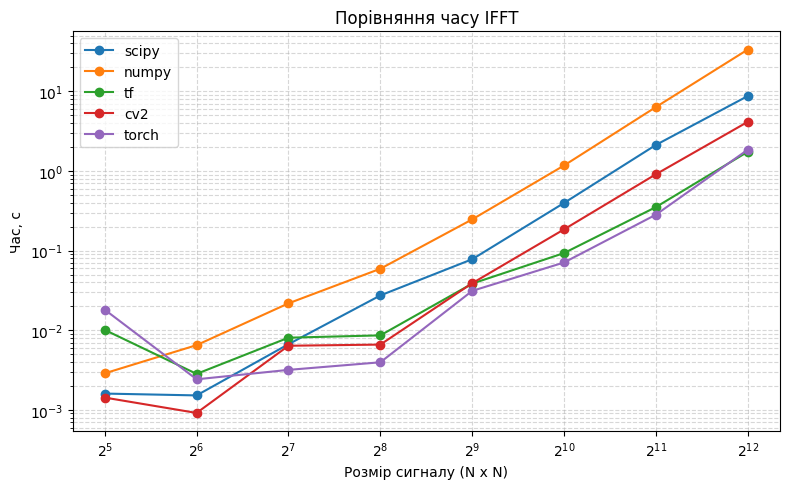

In [4]:
# Графік часу IFFT
plot_metric(
    results,
    sizes,
    metric_suffix='ifft_time',
    title='Порівняння часу IFFT',
    ylabel='Час, с',
    use_log_y=True
)

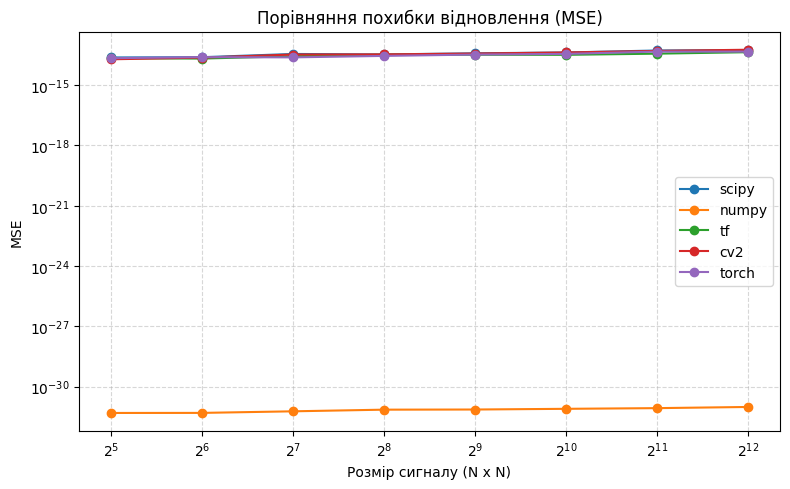

In [5]:
# Графік MSE
plot_metric(
    results,
    sizes,
    metric_suffix='mse',
    title='Порівняння похибки відновлення (MSE)',
    ylabel='MSE',
    use_log_y=True  
)